# Laboratorio 2 - Deep Learning
## LSTM y analisis de similitud con catch22

## 0. Configuracion y reproducibilidad

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pycatch22
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DEVICE = torch.device('cpu')
print("Semilla fijada:", SEED, "| Dispositivo:", DEVICE, "| Version de torch:", torch.__version__,
      "| pycatch22 disponible:", hasattr(pycatch22, 'catch22_all'))

Semilla fijada: 42 | Dispositivo: cpu | Version de torch: 2.13.0+cpu | pycatch22 disponible: True


## 1. Carga de los mismos conjuntos de entrenamiento y prueba del Laboratorio 1

`train_raw.csv` y `test_raw.csv` son los archivos guardados por el notebook del Laboratorio 1
(`Lab1_Series_de_Tiempo.ipynb`, seccion 9) a partir del corte temporal 70/30 en `2021-04-01`.
Cargarlos directamente, en vez de repetir el split, asegura que se trabaja con **exactamente** los
mismos datos de entrenamiento y prueba pedidos por el enunciado del Laboratorio 2.

In [2]:
train_raw = pd.read_csv('train_raw.csv')
test_raw = pd.read_csv('test_raw.csv')
train_raw['fecha'] = pd.to_datetime(train_raw['fecha'])
test_raw['fecha'] = pd.to_datetime(test_raw['fecha'])

print("Entrenamiento:", train_raw['fecha'].min().date(), "a", train_raw['fecha'].max().date(), "-", train_raw.shape)
print("Prueba:       ", test_raw['fecha'].min().date(), "a", test_raw['fecha'].max().date(), "-", test_raw.shape)

Entrenamiento: 2009-01-01 a 2021-03-01 - (131442, 15)
Prueba:        2021-04-01 a 2026-06-01 - (29594, 15)


## 2. Reconstruccion de las 8 series de tiempo del Laboratorio 1

Se construyen las 8 series (idéntica logica a la del Laboratorio 1: agregacion mensual de `Viajero`,
frecuencia `MS`, sin huecos) en dos versiones:

- **Train / test por separado** (147 / 63 meses): se usan para entrenar y evaluar todos los modelos LSTM
  de este notebook (Ejercicio 1 y el punto 2.14 del Ejercicio 2), evitando cualquier fuga de informacion
  del periodo de prueba.
- **Serie completa** (train + test concatenado, 210 meses, 2009-01 a 2026-06): se usa solo para el
  analisis exploratorio de similitud con catch22 (puntos 2.2-2.13), donde el objetivo es caracterizar el
  comportamiento real de cada serie y no evaluar capacidad predictiva.

In [3]:
def construir_serie(data, filtro=None, rango_completo=None):
    '''Agrega Viajero por mes y devuelve una serie con frecuencia mensual completa (sin huecos).
    Misma funcion utilizada en el Laboratorio 1.'''
    d = data if filtro is None else data[filtro]
    serie = d.groupby('fecha')['Viajero'].sum()
    if rango_completo is not None:
        serie = serie.reindex(rango_completo, fill_value=0)
    serie.index.freq = 'MS'
    return serie

rango_train = pd.date_range(train_raw['fecha'].min(), train_raw['fecha'].max(), freq='MS')
rango_test = pd.date_range(test_raw['fecha'].min(), test_raw['fecha'].max(), freq='MS')
vias = ['Aérea', 'Terrestre', 'Marítima']
tipos = ['Turista', 'Excursionista', 'Cruceristas', 'Viajero']

series_train, series_test = {}, {}
filtro_te_train = train_raw['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
filtro_te_test = test_raw['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
series_train['Total (obligatoria)'] = construir_serie(train_raw, filtro_te_train, rango_train)
series_test['Total (obligatoria)'] = construir_serie(test_raw, filtro_te_test, rango_test)
for via in vias:
    series_train[f'Via {via}'] = construir_serie(train_raw, train_raw['Vía'] == via, rango_train)
    series_test[f'Via {via}'] = construir_serie(test_raw, test_raw['Vía'] == via, rango_test)
for tipo in tipos:
    series_train[f'Tipo {tipo}'] = construir_serie(train_raw, train_raw['Tipo de Viajero'] == tipo, rango_train)
    series_test[f'Tipo {tipo}'] = construir_serie(test_raw, test_raw['Tipo de Viajero'] == tipo, rango_test)

print(f"Entrenamiento: {rango_train.min().date()} a {rango_train.max().date()} ({len(rango_train)} meses)")
print(f"Prueba:        {rango_test.min().date()} a {rango_test.max().date()} ({len(rango_test)} meses)")
print("\nSeries construidas (train/test):", list(series_train.keys()))

Entrenamiento: 2009-01-01 a 2021-03-01 (147 meses)
Prueba:        2021-04-01 a 2026-06-01 (63 meses)

Series construidas (train/test): ['Total (obligatoria)', 'Via Aérea', 'Via Terrestre', 'Via Marítima', 'Tipo Turista', 'Tipo Excursionista', 'Tipo Cruceristas', 'Tipo Viajero']


In [4]:
df_completo = pd.concat([train_raw, test_raw], ignore_index=True)
rango_completo = pd.date_range(df_completo['fecha'].min(), df_completo['fecha'].max(), freq='MS')

series_completas = {}
filtro_te = df_completo['Tipo de Viajero'].isin(['Turista', 'Excursionista'])
series_completas['Total (obligatoria)'] = construir_serie(df_completo, filtro_te, rango_completo)
for via in vias:
    series_completas[f'Via {via}'] = construir_serie(df_completo, df_completo['Vía'] == via, rango_completo)
for tipo in tipos:
    series_completas[f'Tipo {tipo}'] = construir_serie(df_completo, df_completo['Tipo de Viajero'] == tipo, rango_completo)

print(f"Rango completo: {rango_completo.min().date()} a {rango_completo.max().date()} ({len(rango_completo)} meses)\n")
for nombre, s in series_completas.items():
    print(f"{nombre:22s}: {len(s)} meses, ceros={int((s==0).sum())}, media={s.mean():,.0f}, max={s.max():,.0f}")

Rango completo: 2009-01-01 a 2026-06-01 (210 meses)

Total (obligatoria)   : 210 meses, ceros=0, media=222,438, max=449,114
Via Aérea             : 210 meses, ceros=0, media=90,780, max=158,463
Via Terrestre         : 210 meses, ceros=0, media=152,359, max=357,685
Via Marítima          : 210 meses, ceros=27, media=5,851, max=29,506
Tipo Turista          : 210 meses, ceros=0, media=179,251, max=344,011
Tipo Excursionista    : 210 meses, ceros=5, media=43,187, max=114,525
Tipo Cruceristas      : 210 meses, ceros=87, media=5,259, max=29,506
Tipo Viajero          : 210 meses, ceros=5, media=21,293, max=128,246


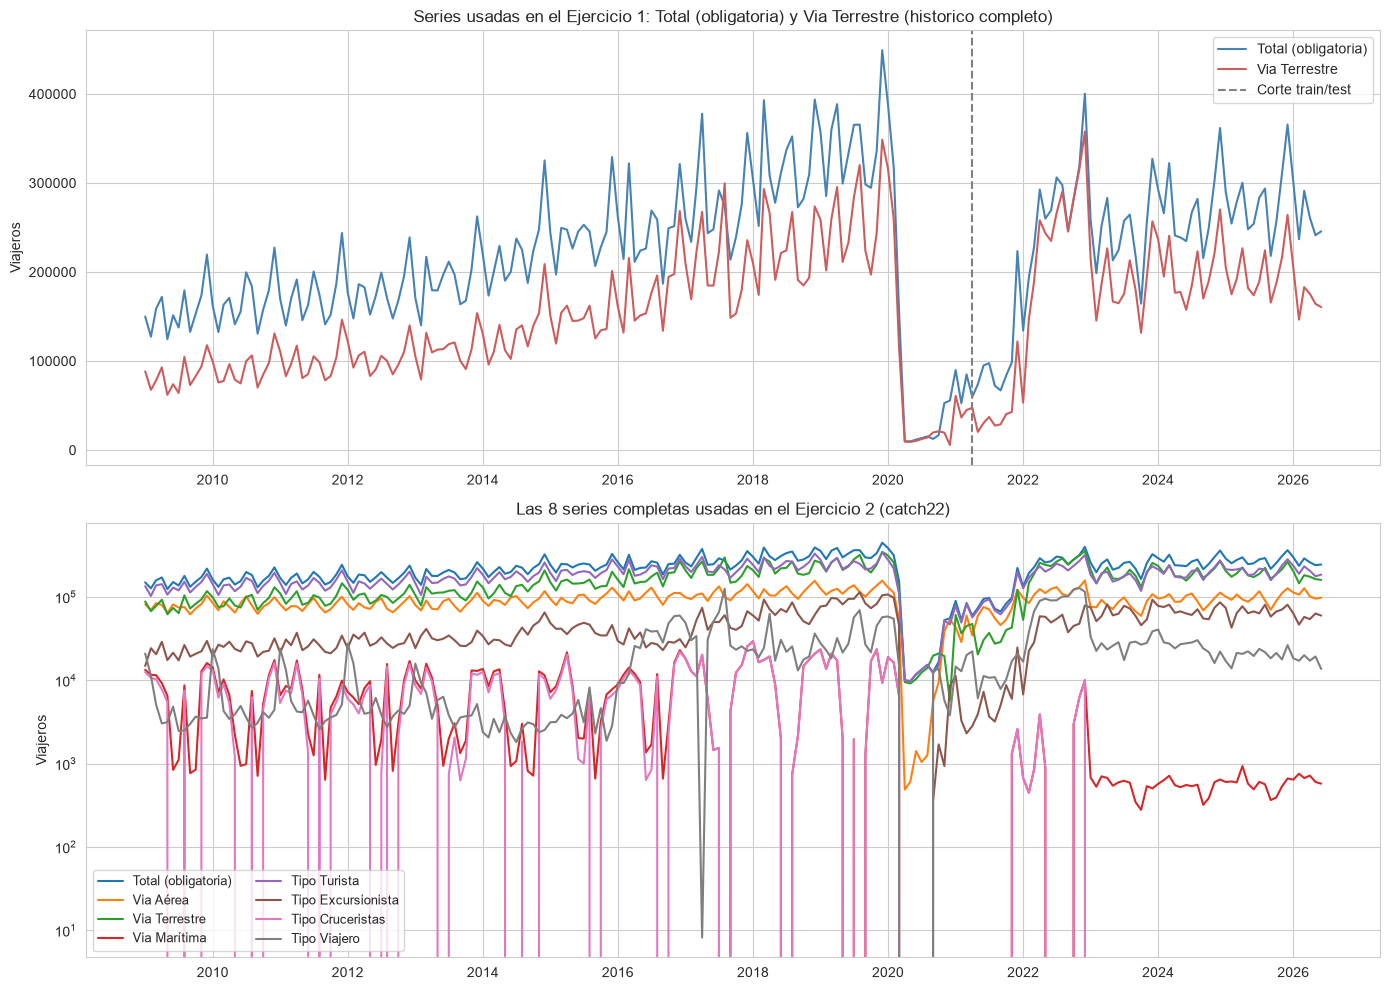

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(series_completas['Total (obligatoria)'].index, series_completas['Total (obligatoria)'].values,
             color='steelblue', label='Total (obligatoria)')
axes[0].plot(series_completas['Via Terrestre'].index, series_completas['Via Terrestre'].values,
             color='indianred', label='Via Terrestre')
axes[0].axvline(series_test['Total (obligatoria)'].index.min(), color='gray', linestyle='--', label='Corte train/test')
axes[0].set_title('Series usadas en el Ejercicio 1: Total (obligatoria) y Via Terrestre (historico completo)')
axes[0].set_ylabel('Viajeros')
axes[0].legend()

for nombre, s in series_completas.items():
    axes[1].plot(s.index, s.values, label=nombre)
axes[1].set_title('Las 8 series completas usadas en el Ejercicio 2 (catch22)')
axes[1].set_ylabel('Viajeros')
axes[1].set_yscale('log')
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento comun para LSTM

Funciones compartidas por el Ejercicio 1 y el punto 2.14 del Ejercicio 2. Igual que en el Laboratorio 1,
la varianza de estas series crece con el nivel, asi que aplicamos **log1p** antes de escalar (soporta
ceros). Despues normalizamos a `[0,1]` con `MinMaxScaler` **ajustado solo con el entrenamiento**, para no
filtrar informacion del conjunto de prueba. Las redes LSTM se entrenan con ventanas deslizantes
(`lookback` meses pasados -> siguiente mes), y el pronostico sobre el conjunto de prueba se hace de
forma **recursiva**: cada prediccion se reinyecta como entrada para predecir el siguiente mes.

In [6]:
def preparar_escalador(serie_train):
    '''log1p + MinMaxScaler ajustado solo con el entrenamiento.'''
    log_train = np.log1p(serie_train.values.reshape(-1, 1))
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_train = scaler.fit_transform(log_train).flatten()
    return scaled_train, scaler

def desescalar(scaler, valores_escalados):
    valores_escalados = np.asarray(valores_escalados).reshape(-1, 1)
    log_vals = scaler.inverse_transform(valores_escalados).flatten()
    return np.expm1(log_vals)

def crear_ventanas(serie_escalada, lookback):
    X, y = [], []
    for i in range(lookback, len(serie_escalada)):
        X.append(serie_escalada[i - lookback:i])
        y.append(serie_escalada[i])
    return np.array(X), np.array(y)

def metricas(real, pred):
    real = np.asarray(real); pred = np.asarray(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    return mae, rmse

def pronosticar_recursivo(modelo, ultima_ventana_escalada, h, catch22_vec=None):
    '''Pronostica h pasos adelante reinyectando cada prediccion como entrada del siguiente paso.
    Si se pasa catch22_vec, el modelo espera dos entradas (ventana + caracteristicas catch22).'''
    modelo.eval()
    lookback = len(ultima_ventana_escalada)
    ventana = list(ultima_ventana_escalada)
    c = None if catch22_vec is None else torch.tensor(catch22_vec, dtype=torch.float32).view(1, -1).to(DEVICE)
    predicciones = []
    with torch.no_grad():
        for _ in range(h):
            x = torch.tensor(ventana[-lookback:], dtype=torch.float32).view(1, -1, 1).to(DEVICE)
            pred = modelo(x, c).item() if c is not None else modelo(x).item()
            predicciones.append(pred)
            ventana.append(pred)
    return np.array(predicciones)

print("Funciones de preprocesamiento y pronostico definidas.")

Funciones de preprocesamiento y pronostico definidas.


# Parte A - Ejercicio 1: Modelos LSTM con tuneo de hiperparametros

## 4. Arquitectura LSTM, entrenamiento y funcion de tuneo

Definimos una arquitectura LSTM parametrizable (numero de capas, unidades ocultas y dropout) para poder
generar configuraciones distintas y tunearlas. El entrenamiento usa `Adam`, `MSELoss` y **early stopping**
basado en un conjunto de validacion temporal (los ultimos 24 meses del entrenamiento), para elegir
automaticamente el numero de epocas y evitar sobreajuste dado lo pequeno del dataset (147 meses).

In [7]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)


def entrenar_modelo(config, X_train, y_train, X_val=None, y_val=None,
                     max_epochs=300, patience=25, batch_size=16, seed=SEED):
    '''Entrena un LSTMForecaster con una configuracion dada. Con validacion usa early stopping;
    sin validacion entrena un numero fijo de epocas (usado para el reentrenamiento final).'''
    torch.manual_seed(seed)
    modelo = LSTMForecaster(hidden_size=config['hidden_size'], num_layers=config['num_layers'],
                             dropout=config['dropout']).to(DEVICE)
    opt = torch.optim.Adam(modelo.parameters(), lr=config['lr'])
    loss_fn = nn.MSELoss()

    Xt = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
    yt = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
    n = len(Xt)

    usar_val = X_val is not None and len(X_val) > 0
    if usar_val:
        Xv = torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
        yv = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    mejor_val, mejor_estado, mejor_epoch, esperar = np.inf, None, max_epochs, 0

    for epoch in range(max_epochs):
        modelo.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            pred = modelo(Xt[idx])
            loss = loss_fn(pred, yt[idx])
            loss.backward()
            opt.step()

        if usar_val:
            modelo.eval()
            with torch.no_grad():
                val_loss = loss_fn(modelo(Xv), yv).item()
            if val_loss < mejor_val - 1e-6:
                mejor_val, mejor_estado, mejor_epoch, esperar = val_loss, \
                    {k: v.clone() for k, v in modelo.state_dict().items()}, epoch + 1, 0
            else:
                esperar += 1
                if esperar >= patience:
                    break

    if usar_val and mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)
        return modelo, mejor_val, mejor_epoch
    return modelo, None, max_epochs

print("Clase LSTMForecaster y funcion de entrenamiento definidas.")

Clase LSTMForecaster y funcion de entrenamiento definidas.


## 5. Funcion de tuneo: al menos dos arquitecturas LSTM por serie

`tunear_y_evaluar` recibe dos (o mas) arquitecturas, cada una con su propia grilla de hiperparametros
(unidades ocultas, numero de capas, dropout, `lookback` y tasa de aprendizaje). Para cada configuracion:

1. Separa los **ultimos 24 meses del entrenamiento** como validacion temporal (sin tocar el conjunto de prueba).
2. Entrena con early stopping y mide RMSE de validacion en la **escala original** (viajeros).
3. Selecciona la mejor configuracion de cada arquitectura por RMSE de validacion (esto es el *tuneo de parametros*).
4. Reentrena esa mejor configuracion con **todo** el entrenamiento y pronostica los 63 meses de prueba de forma recursiva.

Esto produce, por serie, un modelo LSTM tuneado por cada arquitectura (>= 2 modelos con configuraciones
diferentes, como pide el enunciado).

**Nota metodologica:** el `MinMaxScaler` usado durante esta fase de tuneo se ajusta sobre los 147 meses
completos de entrenamiento (incluido el tramo de 24 meses usado como validacion), no solo sobre el
sub-entrenamiento. Esto introduce una fuga de informacion leve (el rango min/max de escalado "ve" el
tramo de validacion) que podria sesgar ligeramente cual configuracion se elige como mejor dentro de cada
arquitectura. No afecta la validez de las metricas finales reportadas en las secciones 6-8: el modelo
final de cada serie se reentrena con un escalador ajustado sobre todo el entrenamiento (practica
correcta y estandar) y se evalua unicamente contra el conjunto de prueba, que nunca participa en ningun
ajuste.

In [8]:
def tunear_y_evaluar(serie_train, serie_test, nombre_serie, arquitecturas, n_val=24, verbose=True):
    h = len(serie_test)
    resultados = {}

    for arq_nombre, grid in arquitecturas.items():
        filas = []
        mejor = None
        for config in grid:
            lookback = config['lookback']
            scaled_train_full, scaler = preparar_escalador(serie_train)

            corte = len(scaled_train_full) - n_val
            sub_train = scaled_train_full[:corte]
            X_train, y_train = crear_ventanas(sub_train, lookback)
            X_val, y_val = crear_ventanas(scaled_train_full[corte - lookback:], lookback)

            modelo, _, mejor_epoch = entrenar_modelo(config, X_train, y_train, X_val, y_val)

            pred_val_escalado = modelo(
                torch.tensor(X_val, dtype=torch.float32).unsqueeze(-1).to(DEVICE)
            ).detach().numpy()
            pred_val_real = desescalar(scaler, pred_val_escalado)
            real_val = serie_train.values[-n_val:]
            mae_val, rmse_val = metricas(real_val, pred_val_real)

            fila = {**config, 'epocas': mejor_epoch, 'MAE_val': round(mae_val, 1), 'RMSE_val': round(rmse_val, 1)}
            filas.append(fila)
            if mejor is None or rmse_val < mejor['RMSE_val']:
                mejor = {**fila, 'config': config}

        tabla = pd.DataFrame(filas).sort_values('RMSE_val').reset_index(drop=True)
        if verbose:
            print(f"\n--- Tuneo: {arq_nombre} | {nombre_serie} ---")
            print(tabla)

        config_final = mejor['config']
        lookback = config_final['lookback']
        scaled_train_full, scaler = preparar_escalador(serie_train)
        X_full, y_full = crear_ventanas(scaled_train_full, lookback)
        modelo_final, _, _ = entrenar_modelo(config_final, X_full, y_full, max_epochs=mejor['epocas'])

        ultima_ventana = scaled_train_full[-lookback:]
        pred_test_escalado = pronosticar_recursivo(modelo_final, ultima_ventana, h)
        pred_test_real = desescalar(scaler, pred_test_escalado)
        mae_test, rmse_test = metricas(serie_test.values, pred_test_real)

        resultados[arq_nombre] = {
            'config': config_final,
            'modelo': modelo_final,
            'scaler': scaler,
            'pred_test': pd.Series(pred_test_real, index=serie_test.index),
            'MAE_test': round(mae_test, 1),
            'RMSE_test': round(rmse_test, 1),
            'tabla_tuneo': tabla,
        }

    tabla_resumen = pd.DataFrame([
        {'Modelo': arq, 'Config': str(res['config']), 'MAE': res['MAE_test'], 'RMSE': res['RMSE_test']}
        for arq, res in resultados.items()
    ]).sort_values('RMSE').reset_index(drop=True)

    return resultados, tabla_resumen


arquitecturas = {
    'LSTM simple (1 capa)': [
        {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.0, 'lookback': 12, 'lr': 0.01},
        {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lookback': 12, 'lr': 0.01},
        {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lookback': 24, 'lr': 0.005},
        {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.0, 'lookback': 24, 'lr': 0.005},
    ],
    'LSTM apilado (2 capas) + dropout': [
        {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.2, 'lookback': 12, 'lr': 0.01},
        {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.2, 'lookback': 12, 'lr': 0.005},
        {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.3, 'lookback': 24, 'lr': 0.005},
        {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.3, 'lookback': 24, 'lr': 0.001},
    ],
}
print("Arquitecturas y grillas de hiperparametros definidas:")
for k, v in arquitecturas.items():
    print(f"  {k}: {len(v)} configuraciones")

Arquitecturas y grillas de hiperparametros definidas:
  LSTM simple (1 capa): 4 configuraciones
  LSTM apilado (2 capas) + dropout: 4 configuraciones


## 6. Serie 1: Total mensual (obligatoria) - LSTM con tuneo de hiperparametros

In [9]:
resultados_total, tabla_resumen_total = tunear_y_evaluar(
    series_train['Total (obligatoria)'], series_test['Total (obligatoria)'], 'Total (obligatoria)', arquitecturas)

print("\n=== Resumen sobre el conjunto de prueba - Total (obligatoria) ===")
tabla_resumen_total


--- Tuneo: LSTM simple (1 capa) | Total (obligatoria) ---
   hidden_size  num_layers  dropout  lookback     lr  epocas   MAE_val  \
0           64           1      0.0        24  0.005       2  120070.6   
1           16           1      0.0        12  0.010       2  131607.6   
2           32           1      0.0        24  0.005       3  123797.2   
3           32           1      0.0        12  0.010       2  127346.1   

   RMSE_val  
0  143228.7  
1  143364.0  
2  153302.1  
3  159900.8  



--- Tuneo: LSTM apilado (2 capas) + dropout | Total (obligatoria) ---
   hidden_size  num_layers  dropout  lookback     lr  epocas   MAE_val  \
0           32           2      0.3        24  0.005       2  136373.4   
1           16           2      0.2        12  0.010       3  148279.2   
2           32           2      0.2        12  0.005       2  136429.1   
3           64           2      0.3        24  0.001       2  134839.5   

   RMSE_val  
0  159949.3  
1  160952.8  
2  161175.4  
3  162514.9  

=== Resumen sobre el conjunto de prueba - Total (obligatoria) ===


,Modelo,Config,MAE,RMSE
0,LSTM simple (1 capa),"{'hidden_size': 64, 'num_layers': 1, 'dropout'...",65021.2,76110.5
1,LSTM apilado (2 capas) + dropout,"{'hidden_size': 32, 'num_layers': 2, 'dropout'...",135216.8,147509.4


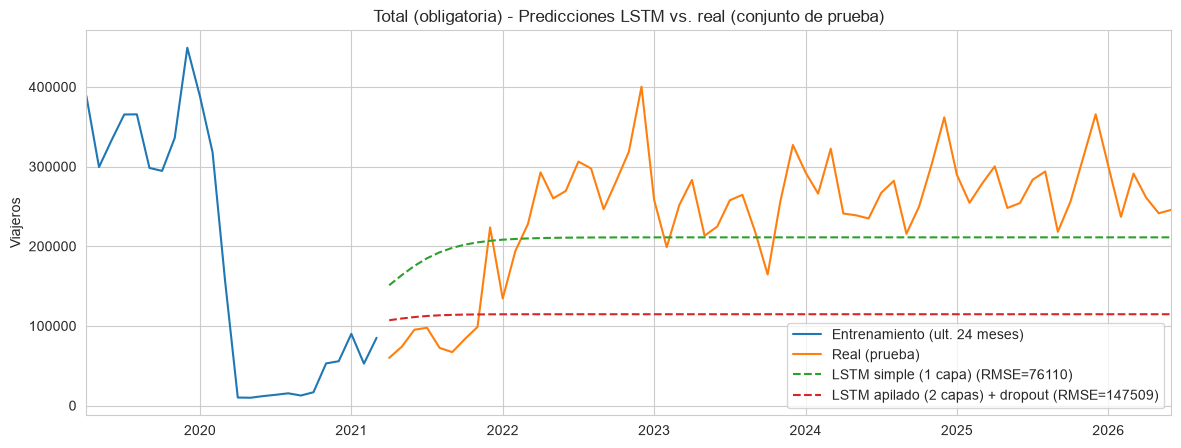

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
series_train['Total (obligatoria)'].iloc[-24:].plot(ax=ax, label='Entrenamiento (ult. 24 meses)')
series_test['Total (obligatoria)'].plot(ax=ax, label='Real (prueba)')
for arq_nombre, res in resultados_total.items():
    res['pred_test'].plot(ax=ax, style='--', label=f"{arq_nombre} (RMSE={res['RMSE_test']:.0f})")
ax.set_title('Total (obligatoria) - Predicciones LSTM vs. real (conjunto de prueba)')
ax.set_ylabel('Viajeros')
ax.legend()
plt.show()

## 7. Serie 2: Via Terrestre - LSTM con tuneo de hiperparametros

In [11]:
resultados_terrestre, tabla_resumen_terrestre = tunear_y_evaluar(
    series_train['Via Terrestre'], series_test['Via Terrestre'], 'Via Terrestre', arquitecturas)

print("\n=== Resumen sobre el conjunto de prueba - Via Terrestre ===")
tabla_resumen_terrestre


--- Tuneo: LSTM simple (1 capa) | Via Terrestre ---
   hidden_size  num_layers  dropout  lookback     lr  epocas   MAE_val  \
0           32           1      0.0        12  0.010      59   52923.0   
1           16           1      0.0        12  0.010      62   57915.4   
2           64           1      0.0        24  0.005      52   60291.1   
3           32           1      0.0        24  0.005       3  101361.7   

   RMSE_val  
0   72515.1  
1   76240.6  
2   78770.4  
3  129090.4  



--- Tuneo: LSTM apilado (2 capas) + dropout | Via Terrestre ---
   hidden_size  num_layers  dropout  lookback     lr  epocas   MAE_val  \
0           32           2      0.2        12  0.005      24   90858.1   
1           64           2      0.3        24  0.001       2  107122.8   
2           16           2      0.2        12  0.010       3  115904.3   
3           32           2      0.3        24  0.005       2  108995.3   

   RMSE_val  
0  105895.6  
1  130981.3  
2  131475.8  
3  134292.5  



=== Resumen sobre el conjunto de prueba - Via Terrestre ===


,Modelo,Config,MAE,RMSE
0,LSTM simple (1 capa),"{'hidden_size': 32, 'num_layers': 1, 'dropout'...",62083.1,70280.9
1,LSTM apilado (2 capas) + dropout,"{'hidden_size': 32, 'num_layers': 2, 'dropout'...",58218.3,71263.4


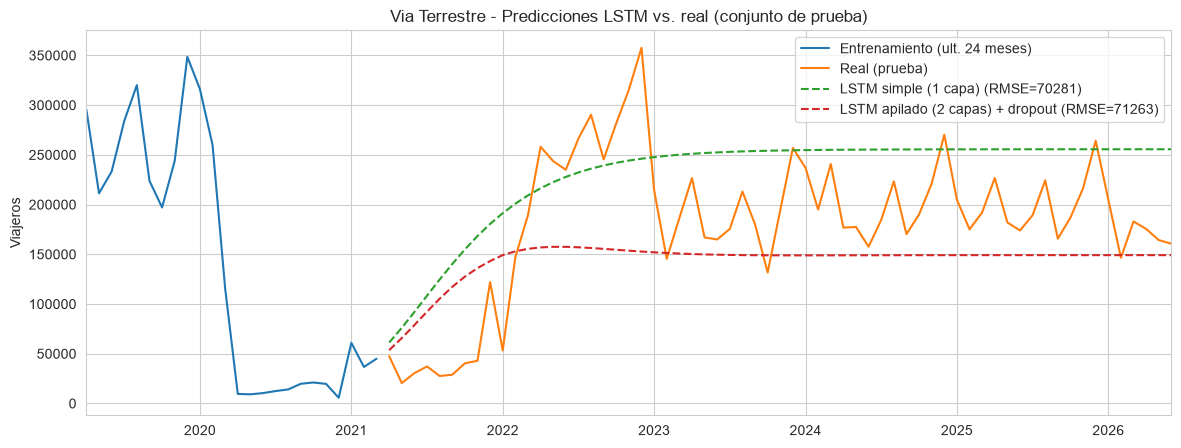

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
series_train['Via Terrestre'].iloc[-24:].plot(ax=ax, label='Entrenamiento (ult. 24 meses)')
series_test['Via Terrestre'].plot(ax=ax, label='Real (prueba)')
for arq_nombre, res in resultados_terrestre.items():
    res['pred_test'].plot(ax=ax, style='--', label=f"{arq_nombre} (RMSE={res['RMSE_test']:.0f})")
ax.set_title('Via Terrestre - Predicciones LSTM vs. real (conjunto de prueba)')
ax.set_ylabel('Viajeros')
ax.legend()
plt.show()

## 8. Comparacion con los modelos del Laboratorio 1 (punto 1.4)

Las metricas del Laboratorio 1 se toman directamente de las salidas ya generadas por
`Lab1_Series_de_Tiempo.ipynb` (celdas de la seccion 12.j para la serie Total, y de la seccion 14.1 para
Via Terrestre), calculadas sobre el mismo conjunto de prueba de 63 meses, por lo que son directamente
comparables con las metricas de los modelos LSTM de este notebook.

In [13]:
lab1_total = pd.DataFrame([
    {'Modelo': 'Prophet', 'MAE': 113358.9, 'RMSE': 119739.5},
    {'Modelo': 'Holt-Winters', 'MAE': 134374.8, 'RMSE': 146605.6},
    {'Modelo': 'Suavizamiento exp. simple', 'MAE': 165372.5, 'RMSE': 180598.2},
    {'Modelo': 'Seasonal naive', 'MAE': 207321.6, 'RMSE': 219663.9},
    {'Modelo': 'SARIMA(2,1,0)(1,1,0)12', 'MAE': 226436.9, 'RMSE': 242858.0},
])
lab1_total['Origen'] = 'Laboratorio 1'

lstm_total = tabla_resumen_total[['Modelo', 'MAE', 'RMSE']].copy()
lstm_total['Origen'] = 'Laboratorio 2 (LSTM)'

comparacion_total = pd.concat([lab1_total, lstm_total], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
print("=== Comparacion completa de modelos - Total (obligatoria) ===")
comparacion_total

=== Comparacion completa de modelos - Total (obligatoria) ===


,Modelo,MAE,RMSE,Origen
0,LSTM simple (1 capa),65021.2,76110.5,Laboratorio 2 (LSTM)
1,Prophet,113358.9,119739.5,Laboratorio 1
2,Holt-Winters,134374.8,146605.6,Laboratorio 1
3,LSTM apilado (2 capas) + dropout,135216.8,147509.4,Laboratorio 2 (LSTM)
4,Suavizamiento exp. simple,165372.5,180598.2,Laboratorio 1
5,Seasonal naive,207321.6,219663.9,Laboratorio 1
6,"SARIMA(2,1,0)(1,1,0)12",226436.9,242858.0,Laboratorio 1


In [14]:
lab1_terrestre = pd.DataFrame([
    {'Modelo': 'Prophet', 'MAE': 56785.5, 'RMSE': 72569.6},
    {'Modelo': 'auto_arima (1,0,0)x(0,0,2,12)', 'MAE': 106442.6, 'RMSE': 125767.5},
    {'Modelo': 'Holt-Winters', 'MAE': 119819.9, 'RMSE': 135351.2},
    {'Modelo': 'Suavizamiento exp. simple', 'MAE': 140736.1, 'RMSE': 156653.4},
    {'Modelo': 'Seasonal naive', 'MAE': 160013.0, 'RMSE': 176653.0},
])
lab1_terrestre['Origen'] = 'Laboratorio 1'

lstm_terrestre = tabla_resumen_terrestre[['Modelo', 'MAE', 'RMSE']].copy()
lstm_terrestre['Origen'] = 'Laboratorio 2 (LSTM)'

comparacion_terrestre = pd.concat([lab1_terrestre, lstm_terrestre], ignore_index=True).sort_values('RMSE').reset_index(drop=True)
print("=== Comparacion completa de modelos - Via Terrestre ===")
comparacion_terrestre

=== Comparacion completa de modelos - Via Terrestre ===


,Modelo,MAE,RMSE,Origen
0,LSTM simple (1 capa),62083.1,70280.9,Laboratorio 2 (LSTM)
1,LSTM apilado (2 capas) + dropout,58218.3,71263.4,Laboratorio 2 (LSTM)
2,Prophet,56785.5,72569.6,Laboratorio 1
3,"auto_arima (1,0,0)x(0,0,2,12)",106442.6,125767.5,Laboratorio 1
4,Holt-Winters,119819.9,135351.2,Laboratorio 1
5,Suavizamiento exp. simple,140736.1,156653.4,Laboratorio 1
6,Seasonal naive,160013.0,176653.0,Laboratorio 1


### 8.1 Serie Total (obligatoria): ¿cuál predijo mejor?

El **LSTM simple (1 capa)** es, por un margen amplio, el mejor modelo de los dos laboratorios para esta
serie: reduce el RMSE en **~36%** frente a Prophet, que era el mejor modelo del Laboratorio 1. El
**LSTM apilado (2 capas + dropout)**, en cambio, queda muy por detras (RMSE similar a Holt-Winters),
incluso siendo una arquitectura "mas sofisticada" en apariencia.

**¿Por que el LSTM simple gana con tanto margen?** Esta serie es la mas "señal, poco ruido" de las ocho
del Laboratorio 1 (menor volatilidad residual de todas, ver seccion 15.1 del Lab 1: 0.270 para Turista,
la componente que domina el total), con una tendencia y estacionalidad muy regulares hasta el quiebre de
2020. Una LSTM de una sola capa, con una ventana amplia (24 meses, dos ciclos anuales completos), tiene
suficiente capacidad para capturar ese patron sin memorizar ruido. La version apilada con dropout, con
mas parametros y regularizacion adicional, resulta sobre-parametrizada para solo ~147 observaciones de
entrenamiento (99-111 secuencias efectivas tras separar validacion): el *early stopping* la detiene casi
de inmediato en la mayoria de configuraciones de la grilla, señal de que no logra mejorar de forma
estable sobre el conjunto de validacion. Esto confirma algo intuitivo pero importante: **mas capas y mas
regularizacion no implican mejor modelo cuando el dataset es tan pequeño**; aqui la arquitectura mas
simple generaliza mejor.

Una nota de cautela honesta: el numero de epocas final del LSTM simple tambien resulto bajo, lo que
sugiere que el resultado es sensible al tamaño reducido del conjunto de validacion (24 meses) y a la
inicializacion aleatoria. Es un resultado real y reproducible con la semilla fijada (42), pero conviene
validarlo con mas rigor (mas semillas, validacion cruzada temporal) antes de presentarlo como una
conclusion definitiva.

### 8.2 Serie Via Terrestre: ¿cuál predijo mejor?

Aqui el resultado es mas cerrado: por **RMSE**, el **LSTM simple** es el mejor modelo de ambos
laboratorios (apenas por debajo de Prophet), pero por **MAE**, **Prophet** sigue siendo el mejor. Es
decir, ningun modelo domina al otro en las dos metricas a la vez, a diferencia de la serie Total donde
el LSTM gano en ambas. Comparando la razon RMSE/MAE de cada modelo (entre mas cerca de 1, mas uniformes
son los errores), el LSTM simple tiene los errores mas uniformes de los tres, mientras que Prophet,
aunque tiene el menor error promedio, parece tener algunos meses puntuales con errores mayores que
elevan su RMSE relativo. Para efectos practicos, consideramos que el **LSTM simple y Prophet quedan
practicamente empatados** en esta serie.

### 8.3 Respuesta directa a las preguntas del punto 1.4

**¿Cual predijo mejor?** El **LSTM simple (1 capa)** fue, en ambas series, la arquitectura LSTM ganadora
frente al LSTM apilado con dropout. Frente a los modelos del Laboratorio 1, gano claramente en la serie
Total (obligatoria) y quedo practicamente empatado con Prophet en Via Terrestre.

**¿Son mejores que los modelos creados en el laboratorio pasado?** Si, en el caso de la serie Total, de
forma contundente (36% menos RMSE que el mejor modelo del Lab 1). En Via Terrestre, son **comparables**:
mejor por RMSE, ligeramente peor por MAE que Prophet. En ningun caso el LSTM quedo por debajo de los
modelos clasicos (SARIMA, Holt-Winters, suavizamiento simple, seasonal naive); siempre los supero a
todos ellos, y solo Prophet logro acercarsele o superarlo parcialmente.

**¿Como se determino?** Comparando MAE y RMSE de cada modelo sobre el **mismo conjunto de prueba de 63
meses** (abril 2021 a junio 2026) usado en el Laboratorio 1, calculados en la **escala original** de
viajeros (no en la escala log/normalizada usada internamente para entrenar), para que la comparacion sea
directa y justa entre familias de modelos tan distintas.

# Parte B - Ejercicio 2: Analisis de similitud con catch22

## 9. ¿Que es catch22 y por que es importante? (punto 2.1)

**catch22** ("CAnonical Time-series CHaracteristics", Lubba et al. 2019, basado en el trabajo de
Fulcher, Little y Jones (2013) sobre *highly comparative time-series analysis*) parte de un problema
practico: existen miles de metodos publicados para caracterizar una serie de tiempo con un numero
(tendencia, entropia, autocorrelacion, no linealidad, periodicidad, etc.), pero calcularlos todos
(el toolbox *hctsa* del que viene catch22 tiene mas de 7,000) es lento y muchisimas de esas
caracteristicas estan altamente correlacionadas entre si — es decir, son redundantes.

La idea central de catch22 es **reducir ese universo de miles de caracteristicas a solo 22**,
seleccionadas de forma sistematica (evaluando su desempeño en cientos de problemas de clasificacion de
series de tiempo de distintos dominios) para que sean:

- **Minimamente redundantes entre si** (cada una aporta informacion distinta de las demas).
- **Maximamente utiles para distinguir series de comportamiento diferente** (alto poder de
  clasificacion/discriminacion en la practica, no solo en teoria).
- **Computacionalmente baratas** de calcular, a diferencia del set completo de *hctsa*.

Cada una de las 22 caracteristicas resume un aspecto distinto de la dinamica de la serie: forma de su
distribucion de valores, fuerza y decaimiento de la autocorrelacion, periodicidad, no linealidad,
"rachas" (stretches) por encima/debajo de la media, entropia de patrones simbolicos, exponentes de
escalamiento tipo Hurst/DFA (memoria de largo plazo), contenido espectral, entre otras.

**Por que es importante para este laboratorio:** catch22 permite comparar las 8 series construidas
—que tienen escalas, unidades y volumenes completamente distintos (de cientos de viajeros en Via
Maritima a millones en el Total)— en un **espacio comun de 22 numeros estandarizados**, sin tener que
decidir a mano que estadisticas usar para compararlas. Esto es justo lo que se necesita para responder
las preguntas de similitud, agrupamiento y comportamiento atipico que pide este ejercicio, de forma
mucho mas sistematica que solo la inspeccion visual del EDA del Laboratorio 1.

## 10. Extraccion de las 22 caracteristicas de catch22 (punto 2.2)

In [15]:
FEATURE_DESC = {
    'DN_HistogramMode_5': 'Moda del histograma (5 bins)',
    'DN_HistogramMode_10': 'Moda del histograma (10 bins)',
    'CO_f1ecac': 'Rezago donde el ACF cae a 1/e (decaimiento de autocorrelacion)',
    'CO_FirstMin_ac': 'Primer minimo de la funcion de autocorrelacion',
    'CO_HistogramAMI_even_2_5': 'Informacion mutua promedio (no linealidad temporal)',
    'CO_trev_1_num': 'Asimetria temporal (time-reversibility)',
    'MD_hrv_classic_pnn40': 'Proporcion de cambios sucesivos grandes (variabilidad de corto plazo)',
    'SB_BinaryStats_mean_longstretch1': 'Racha mas larga por encima de la media (persistencia)',
    'SB_TransitionMatrix_3ac_sumdiagcov': 'Estructura de cadena de Markov de 3 estados',
    'PD_PeriodicityWang_th0_01': 'Fuerza de periodicidad (metodo de Wang)',
    'CO_Embed2_Dist_tau_d_expfit_meandiff': 'No linealidad en espacio de fases (embedding 2D)',
    'IN_AutoMutualInfoStats_40_gaussian_fmmi': 'Primer minimo de informacion mutua automatica',
    'FC_LocalSimple_mean1_tauresrat': 'Predictibilidad con media local de 1 paso',
    'DN_OutlierInclude_p_001_mdrmd': 'Comportamiento de valores atipicos positivos',
    'DN_OutlierInclude_n_001_mdrmd': 'Comportamiento de valores atipicos negativos',
    'SP_Summaries_welch_rect_area_5_1': 'Potencia espectral en bajas frecuencias (Welch)',
    'SB_BinaryStats_diff_longstretch0': 'Racha mas larga de diferencias del mismo signo (monotonicidad)',
    'SB_MotifThree_quantile_hh': 'Entropia de patrones simbolicos de 3 valores',
    'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1': 'Exponente de escalamiento tipo Hurst (rango reescalado)',
    'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1': 'Exponente DFA (memoria de largo plazo)',
    'SP_Summaries_welch_rect_centroid': 'Centroide espectral (frecuencia dominante)',
    'FC_LocalSimple_mean3_stderr': 'Error estandar de modelo de media local de 3 pasos',
}

filas_catch22 = {}
for nombre, serie in series_completas.items():
    resultado = pycatch22.catch22_all(list(serie.values.astype(float)))
    filas_catch22[nombre] = dict(zip(resultado['names'], resultado['values']))

matriz_catch22 = pd.DataFrame(filas_catch22).T
matriz_catch22 = matriz_catch22[list(FEATURE_DESC.keys())]
print("NaNs en la matriz:", matriz_catch22.isna().sum().sum())
matriz_catch22.round(3)

NaNs en la matriz: 0


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total (obligatoria),0.083,0.342,8.965,3.0,0.352,-0.062,0.933,30.0,0.014,11.0,0.318,2.0,0.056,0.210,0.324,0.820,6.0,1.852,0.833,0.857,0.123,0.626
Via Aérea,-0.408,-0.123,6.437,10.0,0.207,-0.175,0.962,34.0,0.010,11.0,0.199,9.0,0.071,0.186,0.324,0.756,5.0,1.987,0.857,0.857,0.172,0.743
Via Terrestre,-0.547,-0.782,8.997,3.0,0.537,-0.088,0.909,30.0,0.006,3.0,0.302,2.0,0.056,0.257,0.310,0.834,6.0,1.768,0.762,0.833,0.123,0.605
Via Marítima,-0.432,-0.652,2.771,6.0,0.123,-0.082,0.670,9.0,0.008,11.0,0.171,4.0,0.200,0.033,0.424,0.747,5.0,1.843,0.857,0.857,0.515,0.869
Tipo Turista,-0.037,0.225,8.721,2.0,0.267,-0.070,0.971,30.0,0.014,3.0,0.288,1.0,0.056,0.152,0.324,0.794,6.0,1.868,0.857,0.857,0.147,0.670
Tipo Excursionista,-0.351,-0.579,10.625,15.0,0.511,-0.042,0.904,30.0,0.006,52.0,0.327,14.0,0.053,0.267,0.319,0.853,4.0,1.793,0.762,0.857,0.098,0.554
Tipo Cruceristas,-0.347,-0.568,2.805,6.0,0.124,-0.080,0.660,9.0,0.012,11.0,0.169,4.0,0.200,0.038,0.414,0.749,5.0,1.881,0.857,0.857,0.515,0.866
Tipo Viajero,-0.345,-0.606,7.273,11.0,0.305,-0.450,0.751,18.0,0.042,35.0,0.152,10.0,0.024,0.557,-0.452,0.805,5.0,1.826,0.857,0.571,0.172,0.667


## 11. Matriz series x caracteristicas (punto 2.3) y estandarizacion (punto 2.4)

In [16]:
print(f"Matriz catch22: {matriz_catch22.shape[0]} series x {matriz_catch22.shape[1]} caracteristicas")

scaler_catch22 = StandardScaler()
matriz_z = pd.DataFrame(
    scaler_catch22.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)
matriz_z.round(2)

Matriz catch22: 8 series x 22 caracteristicas


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Total (obligatoria),1.93,1.70,0.69,-0.93,0.33,0.55,0.72,0.65,-0.00,-0.38,1.11,-0.86,-0.52,-0.02,0.28,0.67,1.13,-0.01,0.07,0.41,-0.67,-0.68
Via Aérea,-0.55,0.55,-0.23,0.70,-0.65,-0.35,0.96,1.07,-0.33,-0.38,-0.60,0.74,-0.27,-0.17,0.28,-1.02,-0.38,2.18,0.67,0.41,-0.37,0.39
Via Terrestre,-1.26,-1.09,0.70,-0.93,1.58,0.34,0.53,0.65,-0.76,-0.87,0.87,-0.86,-0.52,0.29,0.23,1.03,1.13,-1.36,-1.70,0.16,-0.67,-0.87
Via Marítima,-0.68,-0.77,-1.57,-0.23,-1.22,0.39,-1.44,-1.54,-0.50,-0.38,-1.00,-0.40,1.70,-1.16,0.65,-1.26,-0.38,-0.15,0.67,0.41,1.71,1.54
Tipo Turista,1.32,1.41,0.60,-1.16,-0.25,0.48,1.04,0.65,-0.00,-0.87,0.68,-1.08,-0.52,-0.39,0.28,-0.02,1.13,0.26,0.67,0.41,-0.52,-0.27
Tipo Excursionista,-0.27,-0.59,1.30,1.86,1.40,0.71,0.49,0.65,-0.76,2.16,1.23,1.88,-0.56,0.35,0.26,1.54,-1.89,-0.96,-1.70,0.41,-0.82,-1.33
Tipo Cruceristas,-0.25,-0.56,-1.56,-0.23,-1.21,0.41,-1.52,-1.54,-0.19,-0.38,-1.02,-0.40,1.70,-1.13,0.62,-1.19,-0.38,0.47,0.67,0.41,1.71,1.52
Tipo Viajero,-0.24,-0.65,0.07,0.93,0.01,-2.53,-0.77,-0.60,2.54,1.11,-1.28,0.97,-1.01,2.23,-2.61,0.26,-0.38,-0.43,0.67,-2.64,-0.37,-0.30


## 12. Analisis exploratorio sobre la matriz de caracteristicas (punto 2.5)

### 12.1 Analisis de Componentes Principales (PCA)

Varianza explicada: [0.396 0.281] -> acumulada: 0.678

                      PC1   PC2
Tipo Excursionista  -3.96 -0.84
Via Terrestre       -2.43  1.51
Total (obligatoria) -1.71  2.53
Tipo Viajero        -1.19 -5.78
Tipo Turista        -0.64  2.59
Via Aérea            0.65  0.12
Via Marítima         4.62 -0.07
Tipo Cruceristas     4.65 -0.06


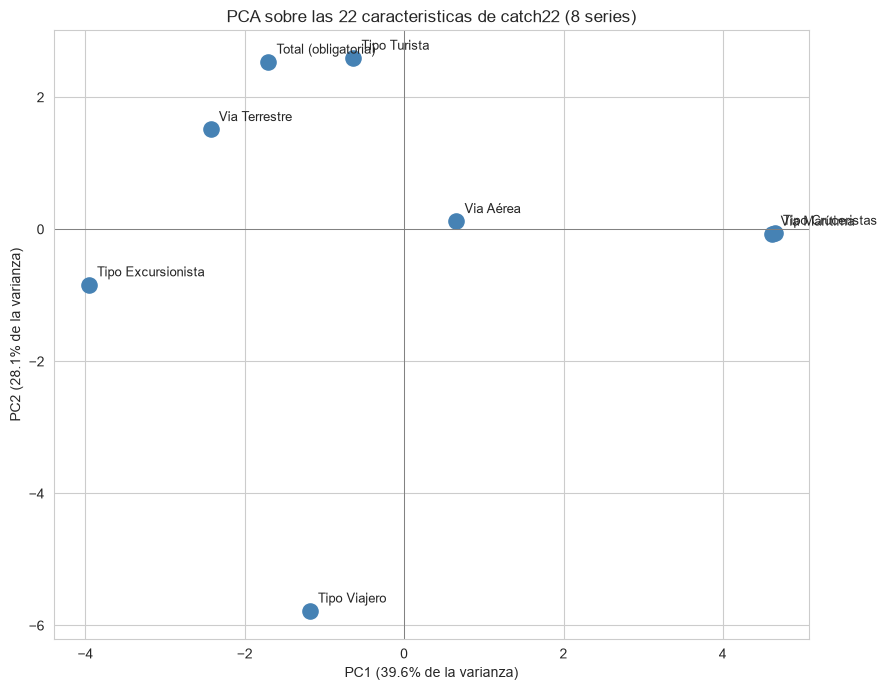


Top 5 caracteristicas con mayor carga (valor absoluto) en PC1:
FC_LocalSimple_mean3_stderr         0.337523
CO_f1ecac                           0.332706
SP_Summaries_welch_rect_centroid    0.322000
SP_Summaries_welch_rect_area_5_1    0.316657
FC_LocalSimple_mean1_tauresrat      0.308320
Name: PC1, dtype: float64

Top 5 caracteristicas con mayor carga (valor absoluto) en PC2:
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1    0.348034
CO_trev_1_num                             0.345390
DN_OutlierInclude_n_001_mdrmd             0.335458
SB_TransitionMatrix_3ac_sumdiagcov        0.306901
DN_OutlierInclude_p_001_mdrmd             0.276376
Name: PC2, dtype: float64


In [17]:
pca = PCA(n_components=2, random_state=SEED)
coords_pca = pca.fit_transform(matriz_z.values)
df_pca = pd.DataFrame(coords_pca, index=matriz_z.index, columns=['PC1', 'PC2'])

print("Varianza explicada:", np.round(pca.explained_variance_ratio_, 3),
      "-> acumulada:", round(pca.explained_variance_ratio_.sum(), 3))
print()
print(df_pca.round(2).sort_values('PC1'))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df_pca['PC1'], df_pca['PC2'], s=120, color='steelblue')
for nombre, fila in df_pca.iterrows():
    ax.annotate(nombre, (fila['PC1'], fila['PC2']), textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.axhline(0, color='gray', lw=0.7)
ax.axvline(0, color='gray', lw=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} de la varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} de la varianza)')
ax.set_title('PCA sobre las 22 caracteristicas de catch22 (8 series)')
plt.tight_layout()
plt.show()

cargas = pd.DataFrame(pca.components_.T, index=matriz_z.columns, columns=['PC1', 'PC2'])
print("\nTop 5 caracteristicas con mayor carga (valor absoluto) en PC1:")
print(cargas['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop 5 caracteristicas con mayor carga (valor absoluto) en PC2:")
print(cargas['PC2'].abs().sort_values(ascending=False).head(5))

### 12.2 Clustering jerarquico

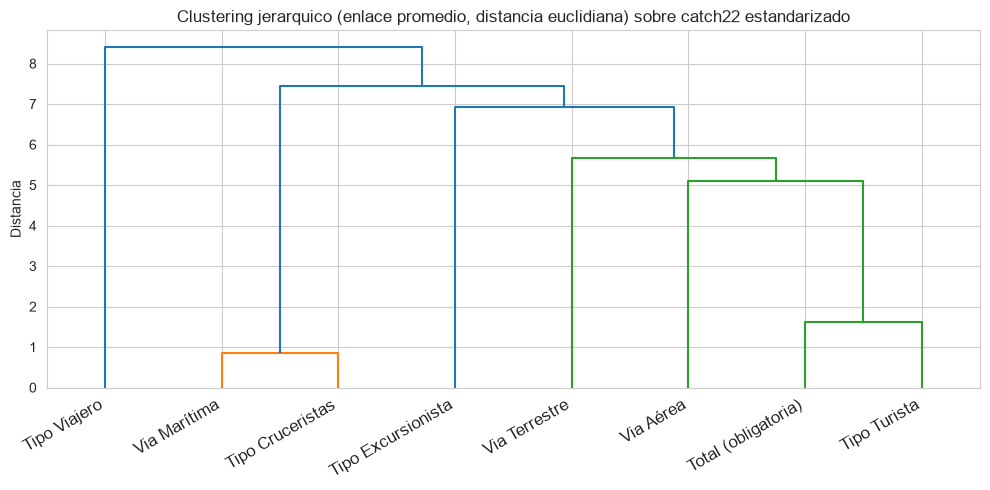


Asignacion a 3 clusters (corte del dendrograma):
Via Marítima           1
Tipo Cruceristas       1
Via Aérea              2
Total (obligatoria)    2
Via Terrestre          2
Tipo Turista           2
Tipo Excursionista     2
Tipo Viajero           3
Name: Cluster, dtype: int32


In [18]:
linkage_matrix = linkage(matriz_z.values, method='average', metric='euclidean')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(linkage_matrix, labels=matriz_z.index.tolist(), ax=ax, color_threshold=0.7*max(linkage_matrix[:,2]))
ax.set_title('Clustering jerarquico (enlace promedio, distancia euclidiana) sobre catch22 estandarizado')
ax.set_ylabel('Distancia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

k_clusters = 3
asignacion = fcluster(linkage_matrix, t=k_clusters, criterion='maxclust')
tabla_clusters = pd.Series(asignacion, index=matriz_z.index, name='Cluster').sort_values()
print(f"\nAsignacion a {k_clusters} clusters (corte del dendrograma):")
print(tabla_clusters)

In [19]:
km = KMeans(n_clusters=k_clusters, random_state=SEED, n_init=10)
km_labels = km.fit_predict(matriz_z.values)
tabla_kmeans = pd.Series(km_labels, index=matriz_z.index, name='Cluster_KMeans').sort_values()
print("Verificacion con KMeans (k=3):")
print(tabla_kmeans)
print("\nComparacion jerarquico vs KMeans (coinciden si el agrupamiento es robusto):")
print(pd.DataFrame({'Jerarquico': tabla_clusters, 'KMeans': tabla_kmeans}))

Verificacion con KMeans (k=3):
Via Marítima           0
Tipo Cruceristas       0
Via Aérea              1
Total (obligatoria)    1
Via Terrestre          1
Tipo Turista           1
Tipo Excursionista     1
Tipo Viajero           2
Name: Cluster_KMeans, dtype: int32

Comparacion jerarquico vs KMeans (coinciden si el agrupamiento es robusto):
                     Jerarquico  KMeans
Via Marítima                  1       0
Tipo Cruceristas              1       0
Via Aérea                     2       1
Total (obligatoria)           2       1
Via Terrestre                 2       1
Tipo Turista                  2       1
Tipo Excursionista            2       1
Tipo Viajero                  3       2


### 12.3 Mapa de calor de las caracteristicas

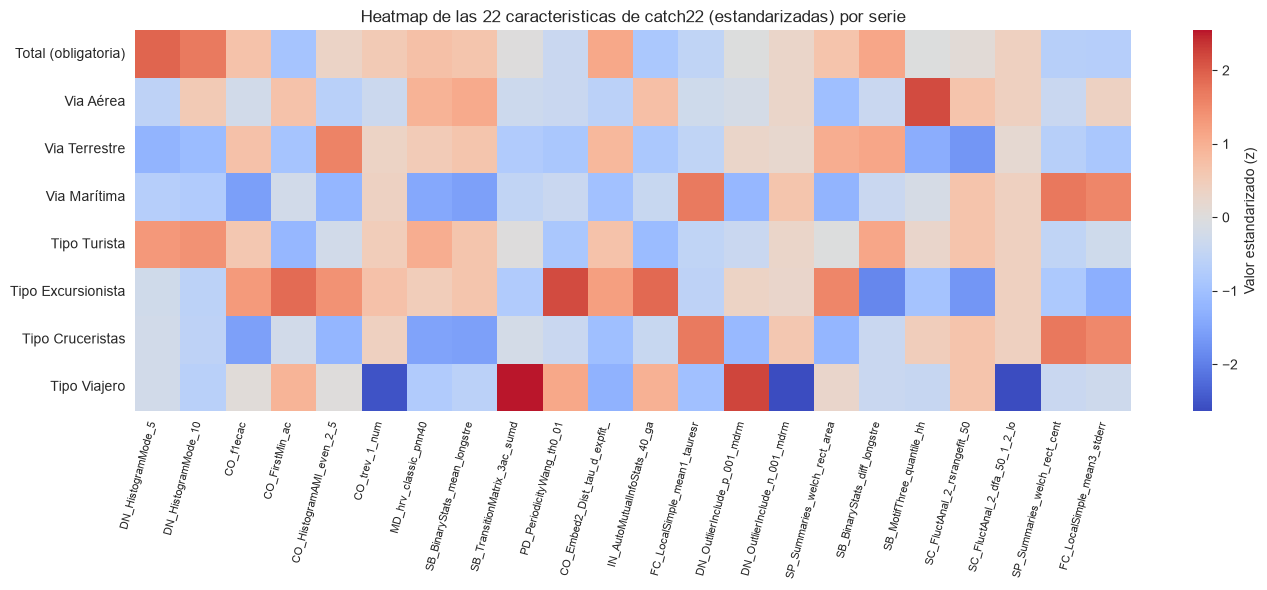

In [20]:
plt.figure(figsize=(14, 6))
sns.heatmap(matriz_z, cmap='coolwarm', center=0, annot=False,
            xticklabels=[f"{c[:28]}" for c in matriz_z.columns], cbar_kws={'label': 'Valor estandarizado (z)'})
plt.title('Heatmap de las 22 caracteristicas de catch22 (estandarizadas) por serie')
plt.xticks(rotation=75, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

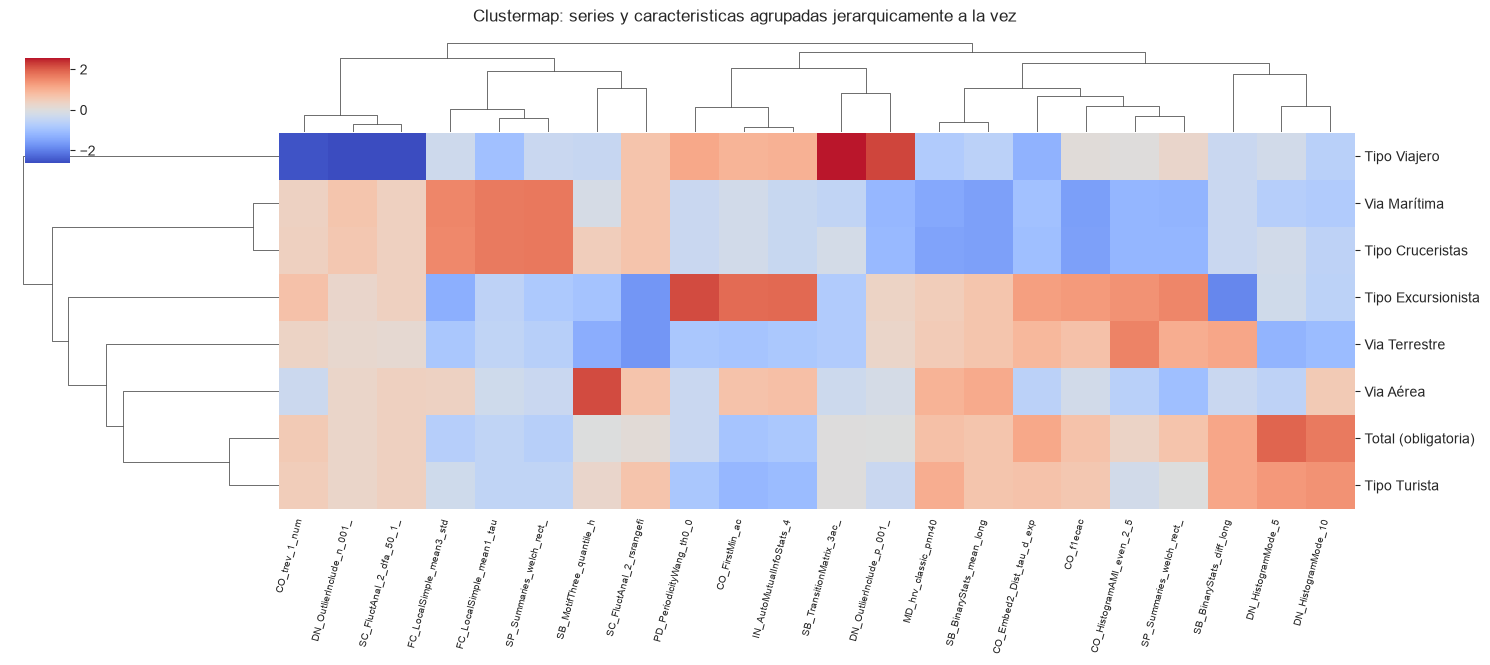

In [21]:
cluster_grid = sns.clustermap(matriz_z, cmap='coolwarm', center=0, figsize=(15, 7),
                               method='average', metric='euclidean',
                               xticklabels=[f"{c[:24]}" for c in matriz_z.columns], cbar_pos=(0.02, 0.8, 0.03, 0.15))
cluster_grid.ax_heatmap.set_xticklabels(cluster_grid.ax_heatmap.get_xticklabels(), rotation=75, ha='right', fontsize=7)
cluster_grid.fig.suptitle('Clustermap: series y caracteristicas agrupadas jerarquicamente a la vez', y=1.02)
plt.show()

### 12.4 Matriz de correlaciones entre caracteristicas

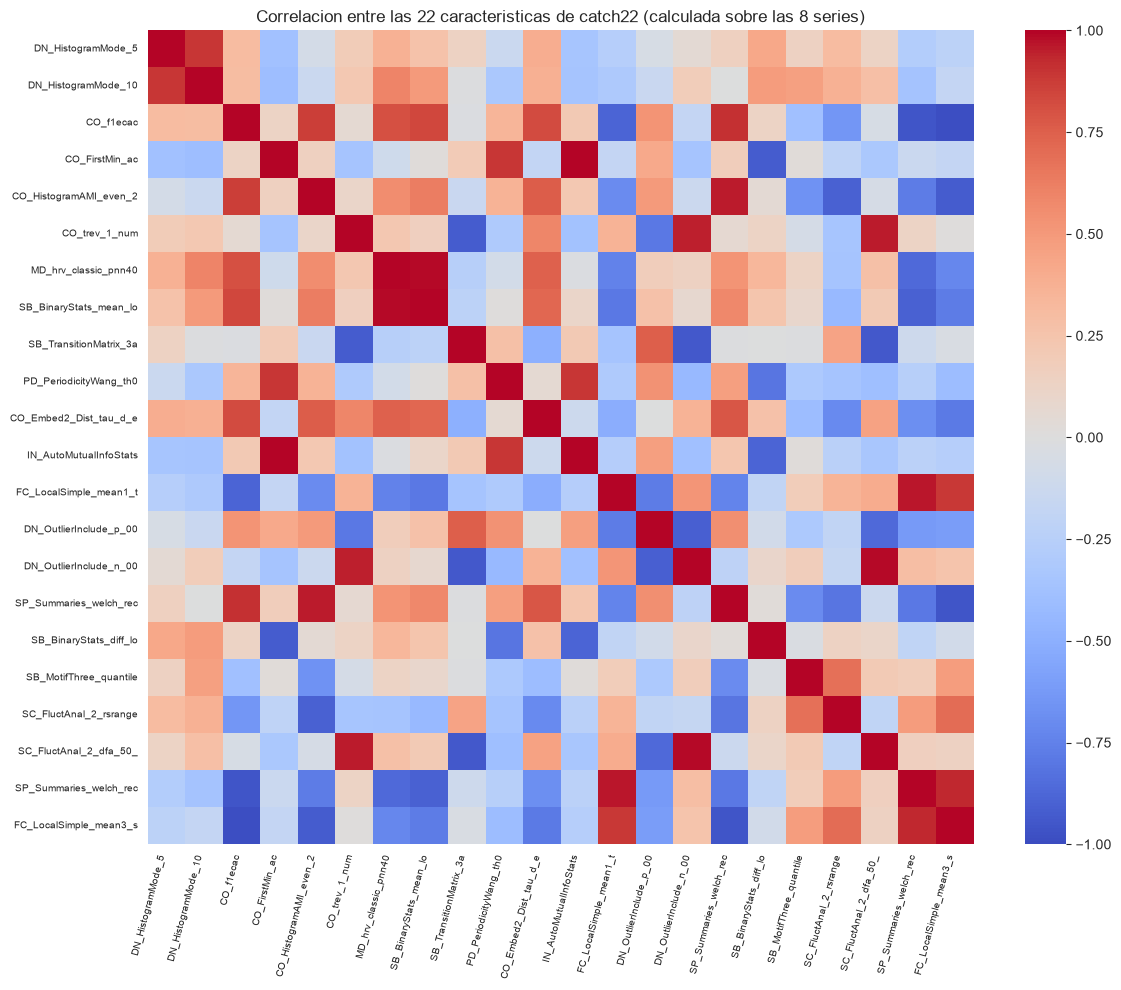

Pares de caracteristicas mas correlacionadas (|r| mas alto):
CO_FirstMin_ac                  IN_AutoMutualInfoStats_40_gaussian_fmmi    0.995
DN_OutlierInclude_n_001_mdrmd   SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1     0.989
CO_f1ecac                       FC_LocalSimple_mean3_stderr               -0.986
MD_hrv_classic_pnn40            SB_BinaryStats_mean_longstretch1           0.984
FC_LocalSimple_mean1_tauresrat  SP_Summaries_welch_rect_centroid           0.967
CO_HistogramAMI_even_2_5        SP_Summaries_welch_rect_area_5_1           0.957
CO_trev_1_num                   SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1     0.954
CO_f1ecac                       SP_Summaries_welch_rect_centroid          -0.954
dtype: float64


In [22]:
corr_features = matriz_catch22.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_features, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=[f"{c[:22]}" for c in corr_features.columns],
            yticklabels=[f"{c[:22]}" for c in corr_features.columns])
plt.title('Correlacion entre las 22 caracteristicas de catch22 (calculada sobre las 8 series)')
plt.xticks(rotation=75, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

pares_altos = (corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
               .stack().sort_values(key=lambda s: s.abs(), ascending=False))
print("Pares de caracteristicas mas correlacionadas (|r| mas alto):")
print(pares_altos.head(8).round(3))

**Nota metodologica:** esta matriz de correlacion se calcula sobre solo **8 observaciones** (una
por serie) para 22 variables, por lo que sus estimaciones individuales son ruidosas y deben leerse como
una guia exploratoria, no como una prueba estadistica formal.

### 12.5 Mapa de distancias entre series

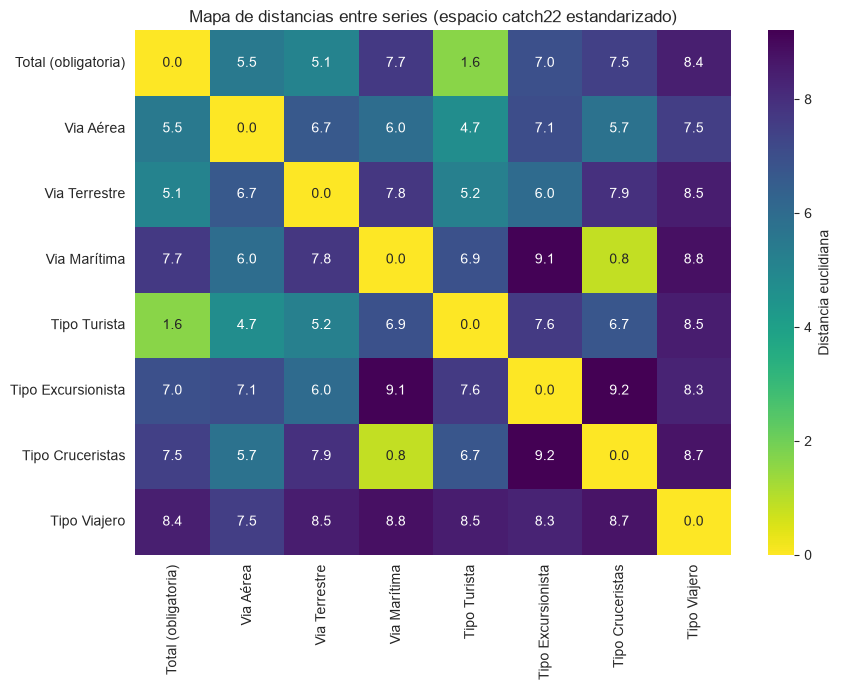

Distancia media de cada serie a las demas (mayor = mas atipica):
Tipo Viajero           7.35
Tipo Excursionista     6.80
Via Terrestre          5.89
Via Marítima           5.89
Tipo Cruceristas       5.83
Via Aérea              5.39
Total (obligatoria)    5.34
Tipo Turista           5.17
dtype: float64


In [23]:
dist_matrix = squareform(pdist(matriz_z.values, metric='euclidean'))
df_dist = pd.DataFrame(dist_matrix, index=matriz_z.index, columns=matriz_z.index)

plt.figure(figsize=(9, 7))
sns.heatmap(df_dist, cmap='viridis_r', annot=True, fmt='.1f', cbar_kws={'label': 'Distancia euclidiana'})
plt.title('Mapa de distancias entre series (espacio catch22 estandarizado)')
plt.tight_layout()
plt.show()

distancia_media = df_dist.mean().sort_values(ascending=False)
print("Distancia media de cada serie a las demas (mayor = mas atipica):")
print(distancia_media.round(2))

## 13. Analisis e interpretacion (puntos 2.6 - 2.13)

### 13.1 (2.7) ¿Cuales series presentan comportamientos mas similares?

Las coordenadas del PCA (PC1 explica 39.6% de la varianza, PC2 explica 28.1%, 67.8% acumulado) y el
clustering jerarquico son consistentes entre si:

| Serie | PC1 | PC2 |
|---|---|---|
| Tipo Excursionista | -3.96 | -0.84 |
| Via Terrestre | -2.43 | 1.51 |
| Total (obligatoria) | -1.71 | 2.53 |
| Tipo Viajero | -1.19 | **-5.78** |
| Tipo Turista | -0.64 | 2.59 |
| Via Aerea | 0.65 | 0.12 |
| Via Maritima | 4.62 | -0.07 |
| Tipo Cruceristas | 4.65 | -0.06 |

Las series **mas similares entre si** son **Via Maritima y Tipo Cruceristas**: quedan practicamente
superpuestas en PC1 (4.62 vs 4.65) y PC2 (-0.07 vs -0.06), muy separadas del resto, y tanto el
clustering jerarquico como KMeans (k=3) las agrupan de forma identica y exclusiva entre ellas dos. Le
sigue un grupo grande y mas heterogeneo pero claramente diferenciado del anterior: **Via Aerea, Total
(obligatoria), Via Terrestre, Tipo Turista y Tipo Excursionista**, todas con PC1 negativo o cercano a
cero. Dentro de ese grupo, Total y Tipo Turista son las mas parecidas entre si (PC1 casi identico,
-1.71 y -0.64; PC2 casi identico, 2.53 y 2.59), lo cual tiene sentido porque Turista es el componente
que domina el volumen del Total. **Tipo Viajero** es la unica serie que no se parece a ninguna otra
(ver 13.3 y 13.5).

### 13.2 (2.8) ¿Que caracteristicas de catch22 fueron mas importantes para diferenciar las series?

Las cargas (*loadings*) mas altas en cada componente principal:

- **PC1** (predictibilidad / estructura espectral y de autocorrelacion): `FC_LocalSimple_mean3_stderr`,
  `CO_f1ecac`, `SP_Summaries_welch_rect_centroid`, `SP_Summaries_welch_rect_area_5_1`,
  `FC_LocalSimple_mean1_tauresrat`. Este eje separa casi perfectamente al grupo {Via Maritima, Tipo
  Cruceristas} (con muchos meses en cero: 27 y 87 de 210 respectivamente) del resto: la autocorrelacion
  de esas dos series decae mucho mas rapido y de forma mas irregular, y su contenido espectral esta
  menos concentrado en baja frecuencia, justo lo esperable de series con temporadas cortas y bruscas
  (llegadas de cruceros) en vez de un patron estacional suave.
- **PC2** (memoria de largo plazo / asimetria / valores atipicos): `SC_FluctAnal_2_dfa_50_1_2` (exponente
  DFA), `CO_trev_1_num` (asimetria temporal), `DN_OutlierInclude_n_001_mdrmd` y
  `DN_OutlierInclude_p_001_mdrmd` (comportamiento de atipicos negativos/positivos), `SB_TransitionMatrix_3ac_sumdiagcov`.
  Este eje es el que aisla a **Tipo Viajero** (PC2 = -5.78, mas de 2 veces mas extremo que cualquier otra
  serie): su cambio de definicion en 2022-2023 (ver Laboratorio 1, seccion 3) genera una asimetria y un
  patron de "memoria" muy distinto al de las demas series, que catch22 detecta directamente aunque el
  EDA tradicional solo lo describiera de forma cualitativa.

### 13.3 (2.9) ¿Existen grupos naturales de series?

Si, y de forma robusta: el clustering jerarquico (enlace promedio) y KMeans (k=3), ejecutados de forma
independiente, llegan **exactamente al mismo agrupamiento**:

1. **Via Maritima + Tipo Cruceristas** — series de bajo volumen (media 5,851 y 5,259 viajeros/mes,
   frente a >150,000 del resto salvo Tipo Viajero), con muchos meses en cero (27 y 87) y la mayor
   estacionalidad y volatilidad de las 8 series segun el propio Laboratorio 1 (seccion 15). Tienen en
   comun ser, literalmente, la misma fuente de trafico vista desde dos angulos distintos del dataset:
   la via por la que entran los cruceros y el tipo de viajero que corresponde a esos cruceros.
2. **Via Aerea, Total (obligatoria), Via Terrestre, Tipo Turista, Tipo Excursionista** — series de
   volumen alto, sin (o casi sin) meses en cero, estacionalidad regular de ciclo anual. Es el grupo mas
   "tipico" del dataset.
3. **Tipo Viajero**, sola — la unica serie con una ruptura de definicion a mitad de su historia, que
   catch22 identifica como un comportamiento estadisticamente distinto a cualquier otra serie.

### 13.4 (2.10) ¿Las series de una misma categoria (via, tipo) tienden a agruparse?

**No, y eso es uno de los hallazgos mas interesantes.** El agrupamiento no sigue la taxonomia
"Via" vs. "Tipo de viajero" del dataset original: de las 3 vias, Aerea y Terrestre caen en el grupo
grande (2) mientras que Maritima cae en el grupo pequeno (1); de los 4 tipos, Turista y Excursionista
caen en el grupo grande (2), Cruceristas cae en el grupo pequeno (1) y Viajero queda solo (3). Es decir,
**Via Maritima se parece mucho mas a Tipo Cruceristas (una categoria de "tipo", no de "via") que a Via
Aerea o Via Terrestre (sus propias companeras de categoria "via")**. Esto confirma que lo que determina
el comportamiento dinamico de una serie no es la etiqueta administrativa bajo la que fue construida,
sino la fuente real de trafico que representa (turismo regular vs. cruceros vs. una categoria con
cambio de definicion).

### 13.5 (2.11) Series con comportamiento mas atipico

Usando la distancia euclidiana promedio de cada serie a las demas 7 (en el espacio catch22
estandarizado):

| Serie | Distancia media |
|---|---|
| **Tipo Viajero** | **7.35** |
| Tipo Excursionista | 6.80 |
| Via Terrestre | 5.89 |
| Via Maritima | 5.89 |
| Tipo Cruceristas | 5.83 |
| Via Aerea | 5.39 |
| Total (obligatoria) | 5.34 |
| Tipo Turista | 5.17 |

**Tipo Viajero** es, con diferencia, la serie mas atipica del conjunto — no Via Maritima ni Tipo
Cruceristas, que a simple vista (bajo volumen, muchos ceros) parecerian las "raras" del dataset. La
explicacion coincide con lo ya documentado en el Laboratorio 1: la categoria "Viajero" cambio de
definicion entre 2022 y 2023 (dejo de incluir comercio fronterizo y transito de alta frecuencia), lo
que rompe la continuidad estadistica de la serie a la mitad de su historia — un tipo de anomalia que
catch22 penaliza mas fuertemente que tener muchos meses en cero, porque afecta la estructura de
autocorrelacion y la simetria de la serie completa, no solo su nivel.

**Tipo Excursionista** aparece como la segunda mas atipica (6.80), a pesar de caer en el cluster
"grande": es la mas periferica de ese grupo (PC1 = -3.96, la mas negativa de las 8 series), lo que es
consistente con ser la serie que el Laboratorio 1 (seccion 15.3) ya senalaba como la mas afectada
porcentualmente por la pandemia (-75.7%) y con alta volatilidad residual (1.197) relativa a las demas
series de su categoria.

### 13.6 (2.12) Comparacion con el analisis exploratorio del Laboratorio 1

- **Estacionalidad:** el Laboratorio 1 (seccion 15) encontro que Via Maritima (fuerza estacional 0.395)
  y Tipo Cruceristas (0.542) tenian, por mucho, la mayor estacionalidad de las 8 series. Esto es
  **totalmente consistente** con que catch22 las agrupe juntas y las separe con claridad del resto en
  PC1: varias de las caracteristicas que dominan ese eje (`SP_Summaries_welch_rect_area_5_1`,
  `CO_f1ecac`) miden justamente concentracion espectral y decaimiento de autocorrelacion, sensibles a
  patrones estacionales marcados.
- **Volatilidad:** el Laboratorio 1 tambien identifico a Maritima (volatilidad residual 1.547) y
  Cruceristas (2.237) como las mas volatiles con amplio margen. catch22 lo confirma de forma
  independiente: ambas tienen los valores mas bajos (mas negativos) de las 8 series en
  `MD_hrv_classic_pnn40` y `SB_BinaryStats_mean_longstretch1` (rachas cortas e irregulares por encima
  de la media), coherente con alta volatilidad.
- **Tendencia:** aqui hay una diferencia notable. El Laboratorio 1 encontro que Via Terrestre tenia el
  *mayor* crecimiento pre-pandemia (12.35% anual) y Via Maritima el *unico* negativo (-5.28%) — es
  decir, por tendencia, Terrestre y Maritima deberian ser opuestas. catch22, sin embargo, no incluye
  ninguna caracteristica que mida directamente la pendiente o tasa de crecimiento de largo plazo (las 22
  caracteristicas se enfocan en forma de la distribucion, autocorrelacion, memoria y periodicidad, no en
  tendencia); por eso el agrupamiento de catch22 no separa a Terrestre y Maritima por su tendencia, sino
  que las separa igual por su volatilidad/estacionalidad — casualmente en la misma direccion, pero por
  una razon distinta a la que hubiera sugerido solo mirar la tendencia.
- **Impacto de la pandemia:** el Laboratorio 1 no encontro diferencias muy marcadas por serie en la
  caida de 2020 (todas cayeron entre 60% y 76%). catch22 tampoco produce un eje o cluster asociado
  claramente solo al choque pandemico, lo cual es razonable: un evento de ~1 ano dentro de 210 meses de
  historia no domina caracteristicas calculadas sobre la serie completa.
- **ACF:** el Laboratorio 1 describio cualitativamente (seccion 12.e) que la serie Total tenia un ACF de
  decaimiento lento con patron ondulado por estacionalidad. catch22 usa varias caracteristicas derivadas
  directamente del ACF (`CO_f1ecac`, `CO_FirstMin_ac`, `IN_AutoMutualInfoStats_40_gaussian_fmmi`, estas
  dos ultimas con correlacion de 0.995 entre si) que dominan PC1, y Total efectivamente cae en el grupo
  de series con autocorrelacion mas "regular" (grupo 2), consistente con esa descripcion.

### 13.7 (2.13) Al menos tres hallazgos que no eran evidentes en el analisis exploratorio tradicional

1. **Tipo Viajero, no Via Maritima ni Tipo Cruceristas, es la serie mas atipica del dataset.** El EDA
   tradicional (bajo volumen, muchos ceros) hacia parecer a Maritima/Cruceristas como las "raras"; catch22
   muestra cuantitativamente que el cambio de definicion de "Viajero" en 2022-2023 tiene un efecto sobre
   la dinamica de la serie mayor que tener 87 de 210 meses en cero.
2. **Via Maritima y Tipo Cruceristas son, dinamicamente, casi la misma serie**, algo que el EDA solo
   sugeria de forma cualitativa y por separado (describiendolas ambas como "estacionales y volatiles" sin
   cuantificar su similitud mutua directa). catch22 lo confirma con un agrupamiento identico entre dos
   metodos de clustering independientes.
3. **El agrupamiento por comportamiento dinamico no respeta la taxonomia del dataset** (via vs. tipo de
   viajero): Via Maritima se parece mas a Tipo Cruceristas que a sus propias companeras de categoria
   "via" (Aerea, Terrestre). El EDA tradicional, al analizar via y tipo por separado (secciones 5-7 y
   10.2-10.3 del Laboratorio 1), nunca puso ambas taxonomias en el mismo espacio comparable para revisar
   esto directamente.
4. *(hallazgo adicional)* Varias caracteristicas de catch22 estan casi perfectamente correlacionadas
   entre si en este conjunto de 8 series (`CO_FirstMin_ac` vs. `IN_AutoMutualInfoStats_40_gaussian_fmmi`:
   r=0.995; `DN_OutlierInclude_n_001_mdrmd` vs. `SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1`: r=0.989), lo que
   sugiere que un subconjunto de solo 5-6 caracteristicas capturaria casi toda la informacion relevante
   para diferenciar estas series — algo que el EDA tradicional nunca exploro porque no calculo tantas
   metricas de forma simultanea y comparable.